In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Load file
data = pd.read_csv('Amazon_Reviews.csv')
data.head()

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


In [3]:
data.shape

(17340, 4)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17340 non-null  object 
 1   cleaned_review         17337 non-null  object 
 2   cleaned_review_length  17340 non-null  int64  
 3   review_score           17340 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 542.0+ KB


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
cleaned_review_length,17340.0,30.300461,35.83654,0.0,9.0,20.0,38.0,571.0
review_score,17340.0,3.649077,1.67350,1.0,2.0,5.0,5.0,5.0


In [6]:
# Missing Values
data.isnull().sum()

sentiments               0
cleaned_review           3
cleaned_review_length    0
review_score             0
dtype: int64

In [7]:
data.dropna(subset=['cleaned_review'], inplace=True)

In [8]:
# Renaming the columns
data.rename(columns=
            {
                'sentiments':'sentiment',
                'cleaned_review':'review',
                'cleaned_review_length':'review_length',
                'review_score':'rating'
            }, inplace=True
)
data.head()

,sentiment,review,review_length,rating
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


In [9]:
# Class distribution
data['sentiment'].value_counts()

sentiment
positive    9503
neutral     6300
negative    1534
Name: count, dtype: int64

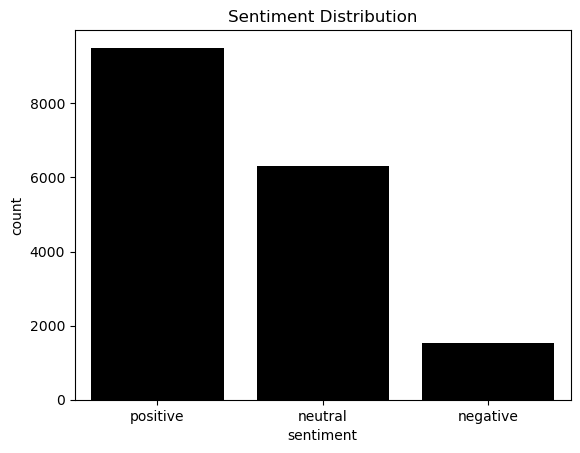

In [10]:
sns.countplot(x='sentiment', data=data, color='black')
plt.title('Sentiment Distribution')
plt.show()

In [11]:
# Review length
data['review_length'].describe()

count    17337.000000
mean        30.305705
std         35.837424
min          0.000000
25%          9.000000
50%         20.000000
75%         38.000000
max        571.000000
Name: review_length, dtype: float64

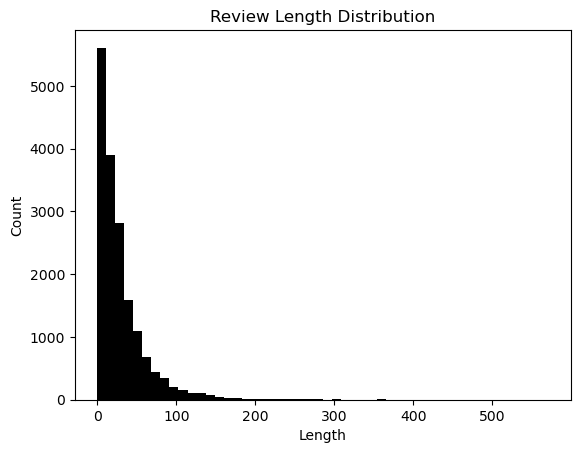

In [12]:
plt.hist(data['review_length'], bins=50, color='black')
plt.title('Review Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

In [13]:
data.to_csv('cleaned_amazon_reviews', index=False)

## EDA

In [14]:
from wordcloud import WordCloud
!pip install wordcloud

### 📊 BUSINESS QUESTION 1
### How is sentiment distributed?

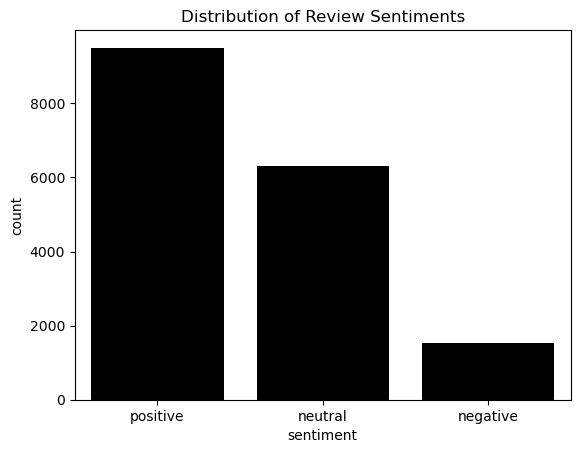

In [15]:
sns.countplot(x='sentiment', data=data, color='black')
plt.title('Distribution of Review Sentiments')
plt.show()

#### Insight
#### Most customers are satisfied with the products, but negative reviews represent potential improvement areas. Even a small percentage of negative feedback can significantly impact brand reputation and sales.

### ⭐ BUSINESS QUESTION 2
### How does rating relate to sentiment?

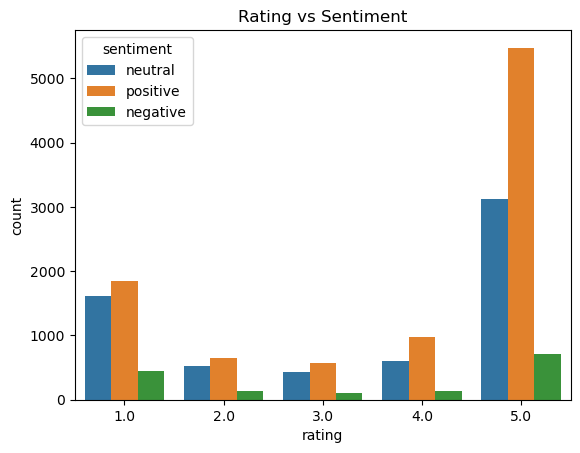

In [16]:
sns.countplot(x='rating', hue='sentiment', data=data)
plt.title('Rating vs Sentiment')
plt.show()

#### Insights
#### Customer sentiment does not perfectly match star ratings. While 5-star reviews are mostly positive, low-star ratings still contain many neutral comments, suggesting that customers often provide balanced feedback rather than purely negative opinions.

### ✍️ BUSINESS QUESTION 3
### Do negative reviews tend to be longer?

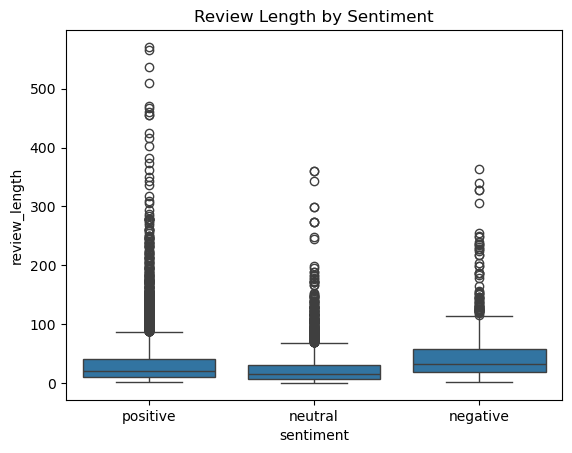

In [17]:
sns.boxplot(x='sentiment', y='review_length', data=data)
plt.title('Review Length by Sentiment')
plt.show()

#### Insights
#### Customers who have negative experiences tend to write significantly longer reviews, indicating that dissatisfied customers provide more detailed feedback. This suggests that negative reviews are a valuable source for identifying product issues and improvement opportunities.

### ☁️ BUSINESS QUESTION 4
### Most Common Words (All Reviews)

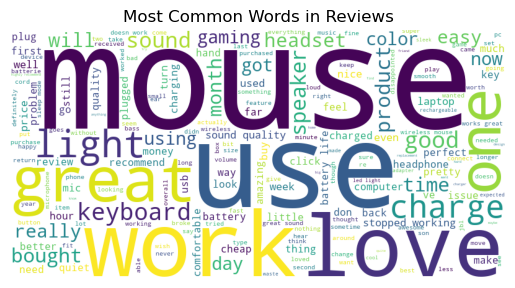

In [18]:
all_words = "".join(data['review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.imshow(wordcloud, cmap='coolwarm')
plt.axis('off')
plt.title('Most Common Words in Reviews')
plt.show()

#### Insights
#### Customers primarily discuss real-world usage, product performance, and long-term durability. Frequent appearance of feature-related words suggests that functionality and reliability are the key drivers of customer satisfaction.

### 😊 BUSINESS QUESTION 5
### Words in Positive Reviews

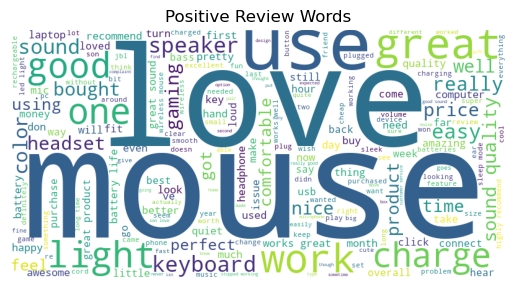

In [19]:
positive_reviews = " ".join(data[data['sentiment']=='positive']['review'])

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
plt.imshow(wordcloud_pos, cmap='coolwarm')
plt.axis('off')
plt.title('Positive Review Words')
plt.show()

#### Insights
#### Positive reviews are strongly driven by usability, product quality, comfort, and value for money. Emotional words like “love” and “great” highlight strong customer satisfaction, particularly for tech accessories such as mouse, keyboard, and headset products.

### 😡 BUSINESS QUESTION 6
### Words in Negative Reviews

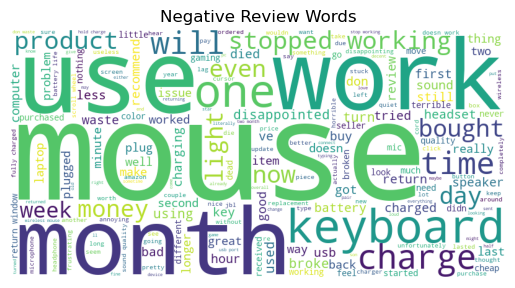

In [20]:
negative_reviews = " ".join(data[data['sentiment']=='negative']['review'])

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)
plt.imshow(wordcloud_neg, cmap='coolwarm')
plt.axis('off')
plt.title('Negative Review Words')
plt.show()

#### Insights
#### Negative reviews are primarily driven by product reliability issues, battery problems, and short product lifespan. Frequent mentions of returns and wasted money indicate strong dissatisfaction and highlight key areas for product improvement.

### 🔝 BUSINESS QUESTION 7
### Top 20 Frequent Words

In [21]:
from collections import Counter

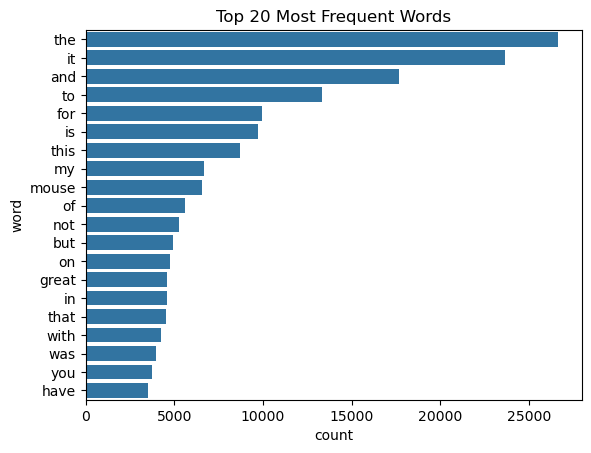

In [22]:
words = " ".join(data['review']).split()
word_count = Counter(words)

common_words = pd.DataFrame(word_count.most_common(20), columns=['word', 'count'])

sns.barplot(x='count', y='word', data=common_words)
plt.title('Top 20 Most Frequent Words')
plt.show()

#### Insights
#### Common stopwords dominate the raw text, highlighting the need for stopword removal during preprocessing. The presence of words like “mouse,” “great,” and “not” indicates that the dataset contains strong product-specific and sentiment-related language suitable for building a sentiment analysis model.

## NLP Processing + Model Training

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

!pip install nltk

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [24]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [25]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # <-- NEW tokenizer file
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [26]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [27]:
def preprocess_text(text):

    #1.lowercase
    text = text.lower()

    #2.remove punctuation & numbers
    text = re.sub(r'[^a-z\s]','', text)

    #3. tokeniztion
    tokens = word_tokenize(text)

    #4. remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    #5. lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [28]:
data['preprocessed_review'] = data['review'].apply(preprocess_text)
data.head()

,sentiment,review,review_length,rating,preprocessed_review
0,positive,i wish would have gotten one earlier love it a...,19,5.0,wish would gotten one earlier love make workin...
1,neutral,i ve learned this lesson again open the packag...,88,1.0,learned lesson open package use product right ...
2,neutral,it is so slow and lags find better option,9,2.0,slow lag find better option
3,neutral,roller ball stopped working within months of m...,12,1.0,roller ball stopped working within month minim...
4,neutral,i like the color and size but it few days out ...,21,1.0,like color size day return period hold charge


In [29]:
encoder = LabelEncoder()

data['sentiment_encoded'] = encoder.fit_transform(data['sentiment'])
data[['sentiment', 'sentiment_encoded']].head()

,sentiment,sentiment_encoded
0,positive,2
1,neutral,1
2,neutral,1
3,neutral,1
4,neutral,1


In [30]:
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'negative': 0, 'neutral': 1, 'positive': 2}


In [31]:
X = data['preprocessed_review']
y = data['sentiment_encoded']

In [32]:
#converting text to numbers

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_vectorized = vectorizer.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [34]:
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
print('Logistic Regression Accuracy : ', accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy :  0.8281430219146482


In [35]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
print('Multinomial Accuracy : ', accuracy_score(y_test, nb_pred))

Multinomial Accuracy :  0.7061707035755479


In [36]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print('Random Forest Model Accuracy : ', accuracy_score(y_test, rf_pred))

Random Forest Model Accuracy :  0.8725490196078431


## Business NLP Insights

### 🧠 BUSINESS QUESTION 1
### What words drive POSITIVE sentiment?

In [37]:
positive_df = data[data['sentiment']=='positive']

pos_words = " ".join(positive_df['preprocessed_review']).split()
pos_common = Counter(pos_words).most_common(20)

pos_df = pd.DataFrame(pos_common, columns=['word', 'count'])
pos_df

,word,count
0,great,4116
1,mouse,3661
2,love,2744
3,sound,2706
4,work,2654
5,good,2152
6,use,2072
7,like,1751
8,light,1751
9,one,1592


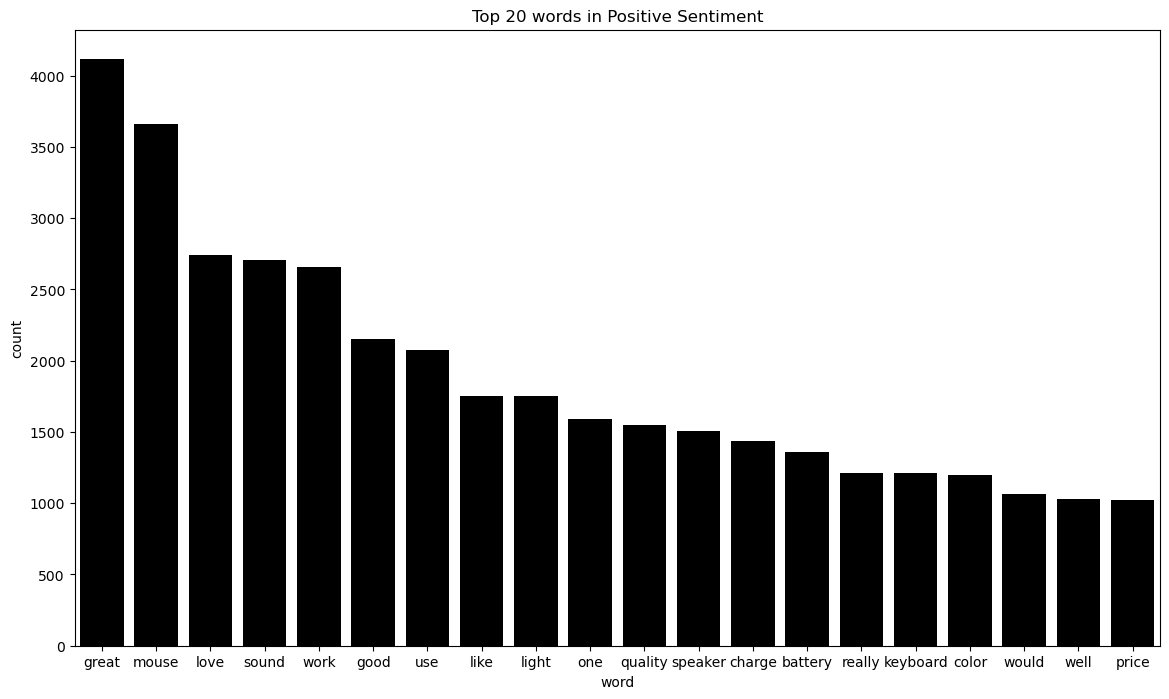

In [38]:
plt.figure(figsize=(14, 8))
sns.barplot(x='word', y='count', data=pos_df, color='black')
plt.title('Top 20 words in Positive Sentiment')
plt.show()

### 😡 BUSINESS QUESTION 2
### What words drive NEGATIVE sentiment?

In [39]:
negative_df = data[data['sentiment']=='negative']
neg_words = " ".join(negative_df['preprocessed_review']).split()
neg_common = Counter(neg_words).most_common(20)

neg_df = pd.DataFrame(neg_common, columns=['word', 'count'])
neg_df

,word,count
0,mouse,934
1,work,468
2,working,391
3,one,391
4,use,386
5,charge,378
6,month,370
7,would,320
8,keyboard,300
9,time,296


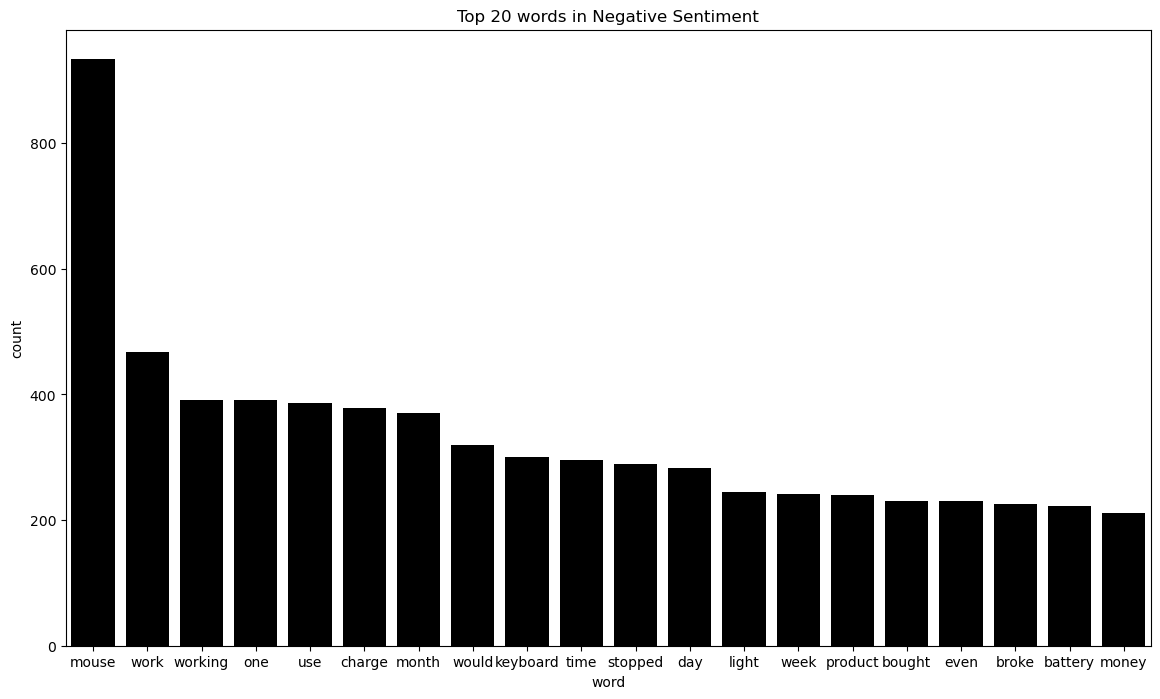

In [40]:
plt.figure(figsize=(14, 8))
sns.barplot(x='word', y='count', data=neg_df, color='black')
plt.title('Top 20 words in Negative Sentiment')
plt.show()

### ⚖️ BUSINESS QUESTION 3
### Compare Positive vs Negative Keywords

In [41]:
comparison = pos_df.merge(neg_df, on='word', how='outer', suffixes=("_pos", "_neg")).fillna(0)
comparison

,word,count_pos,count_neg
0,battery,1359.0,223.0
1,bought,0.0,231.0
2,broke,0.0,225.0
3,charge,1439.0,378.0
4,color,1201.0,0.0
5,day,0.0,283.0
6,even,0.0,230.0
7,good,2152.0,0.0
8,great,4116.0,0.0
9,keyboard,1210.0,300.0


### ⭐ BUSINESS QUESTION 4
### Review Score vs Sentiment

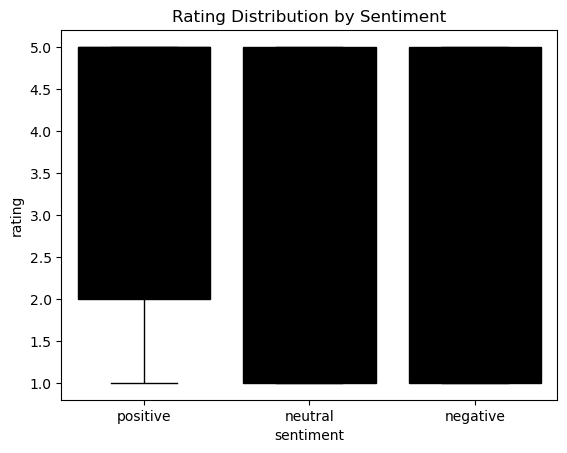

In [42]:
sns.boxplot(x='sentiment', y='rating', data=data, color='black')
plt.title('Rating Distribution by Sentiment')
plt.show()

### 🧾 BUSINESS QUESTION 5
### Average Review Length by Sentiment

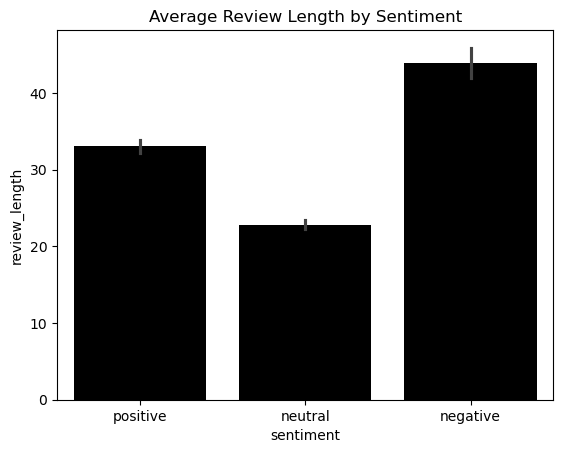

In [43]:
sns.barplot(x='sentiment', y='review_length', data=data, color='black')
plt.title('Average Review Length by Sentiment')
plt.show()

In [44]:
data.to_csv('Amazon_Reviews_Final.csv', index=False)

In [45]:
pos_df.to_csv('Positive_Keywords.csv', index=False)
neg_df.to_csv('Negative_Keywords.csv', index=False)